In [46]:
import pandas as pd
import json

query_df = pd.DataFrame(json.load(open('../data/v3_sources/v3_combined_ALL_with_oracle.json')))
full_source_df = pd.DataFrame(query_df['truth'].explode().to_list())

In [42]:
t = (
    full_source_df
         .groupby('url')
         ['llama_label']
         .value_counts()
         .unstack()
         .fillna(0)
         .pipe(lambda df: (df > 0).astype(int))
         # .mean()
         # .plot(kind='bar')
         .pipe(lambda df: df.divide(df.sum(axis=1), axis=0))
         .mean()
         # .plot(kind='bar')
)

In [48]:
from sentence_transformers import SentenceTransformer

# 1. Load a pretrained Sentence Transformer model
model = SentenceTransformer("all-MiniLM-L6-v2")

# 2. Calculate embeddings by calling model.encode()
query_embeddings =  model.encode(query_df['query'].tolist(), show_progress_bar=True)
source_embeddings = model.encode(full_source_df['Information'].tolist(), show_progress_bar=True)

/Users/spangher/miniconda3/lib/python3.12/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


Batches:   0%|          | 0/1606 [00:00<?, ?it/s]

Batches:   0%|          | 0/11880 [00:00<?, ?it/s]

In [56]:
source_embeddings_df = pd.DataFrame(source_embeddings)

In [57]:
source_embeddings_df[['url', 'Name']] = full_source_df[['url', 'Name']]

In [58]:
query_embeddings_df = pd.DataFrame(query_embeddings)

In [60]:
query_embeddings_df['url'] = query_df['url']

In [63]:
full_emb_df = source_embeddings_df.merge(query_embeddings_df, on='url', suffixes=('__source', '__query'))

In [65]:
source_emb_cols = list(filter(lambda x: x.endswith('__source'), full_emb_df))

In [66]:
query_emb_cols = list(filter(lambda x: x.endswith('__query'), full_emb_df))

In [73]:
from scipy.spatial.distance import cosine
from tqdm.auto import tqdm
tqdm.pandas()

In [74]:
full_source_df['cosine_sim'] = full_emb_df.progress_apply(lambda x: 1 - cosine(x[source_emb_cols], x[query_emb_cols]), axis=1)

  0%|          | 0/380138 [00:00<?, ?it/s]

<Axes: xlabel='llama_label', ylabel='cosine_sim'>

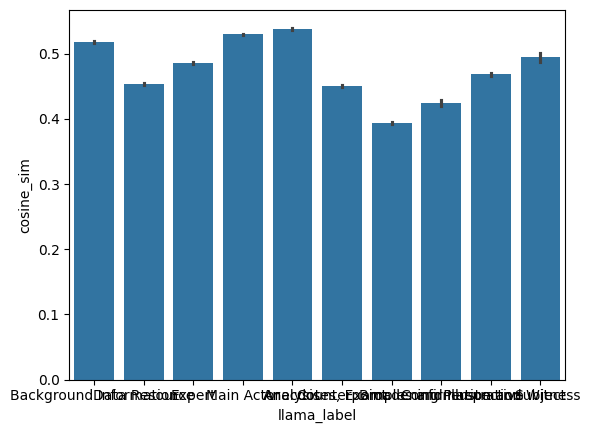

In [84]:
import seaborn as sns
sns.barplot(full_source_df, x='llama_label', y='cosine_sim')